In [1]:
import os,warnings
import matplotlib.pyplot as plt
from matplotlib import gridspec

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl6StatusC1EN10tensorflow5error4CodeESt17basic_string_viewIcSt11char_traitsIcEENS_14SourceLocationE']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZTVN10tenso

In [3]:
def set_seed(seed=14325):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
set_seed(14325)

In [4]:
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')
warnings.filterwarnings("ignore")

In [5]:
ds_train_ = image_dataset_from_directory(
    '/kaggle/input/stft-sz12/STFT_SZ/train',
    labels='inferred',
    label_mode='binary',
    image_size=[227, 227],
    interpolation='nearest',
    batch_size=64,
    shuffle=True,
)

Found 1606 files belonging to 2 classes.


In [6]:
def convert_to_float(image, label):
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    return image, label
AUTOTUNE = tf.data.experimental.AUTOTUNE

In [7]:
ds_train = (
    ds_train_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

In [8]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    # Block One
    layers.Conv2D(filters=32, kernel_size=3, activation='relu', padding='same',
                  input_shape=[227,227, 3]),
    layers.MaxPool2D(),

    # Block Two
    layers.Conv2D(filters=64, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPool2D(),

    # Block Three
    layers.Conv2D(filters=128, kernel_size=3, activation='relu', padding='same'),
    layers.Conv2D(filters=128, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPool2D(),

    # Head
    layers.Flatten(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    
    
   
    layers.Dense(2, activation='softmax'),
])

In [9]:



model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

In [10]:
ds_valid_ = image_dataset_from_directory(
    '/kaggle/input/stft-sz12/STFT_SZ/test',
    labels='inferred',
    label_mode='binary',
    image_size=[227,227],
    interpolation='nearest',
    batch_size=64,
    shuffle=False,
)
ds_valid = (
    ds_valid_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

Found 308 files belonging to 2 classes.


In [11]:
history = model.fit(
    ds_train,
    validation_data=ds_valid,
    epochs=120,
)

Epoch 1/120
26/26 [==============================] - 25s 435ms/step - loss: 0.7051 - accuracy: 0.5430 - val_loss: 0.6937 - val_accuracy: 0.5162
Epoch 2/120
26/26 [==============================] - 2s 96ms/step - loss: 0.6904 - accuracy: 0.5442 - val_loss: 0.6930 - val_accuracy: 0.5162
Epoch 3/120
26/26 [==============================] - 2s 94ms/step - loss: 0.6897 - accuracy: 0.5411 - val_loss: 0.6930 - val_accuracy: 0.5162
Epoch 4/120
26/26 [==============================] - 2s 94ms/step - loss: 0.6876 - accuracy: 0.5436 - val_loss: 0.6935 - val_accuracy: 0.5162
Epoch 5/120
26/26 [==============================] - 2s 93ms/step - loss: 0.6856 - accuracy: 0.5380 - val_loss: 0.6939 - val_accuracy: 0.5292
Epoch 6/120
26/26 [==============================] - 2s 94ms/step - loss: 0.6821 - accuracy: 0.5548 - val_loss: 0.6951 - val_accuracy: 0.5455
Epoch 7/120
26/26 [==============================] - 2s 94ms/step - loss: 0.6784 - accuracy: 0.5473 - val_loss: 0.6940 - val_accuracy: 0.5260
Epoc

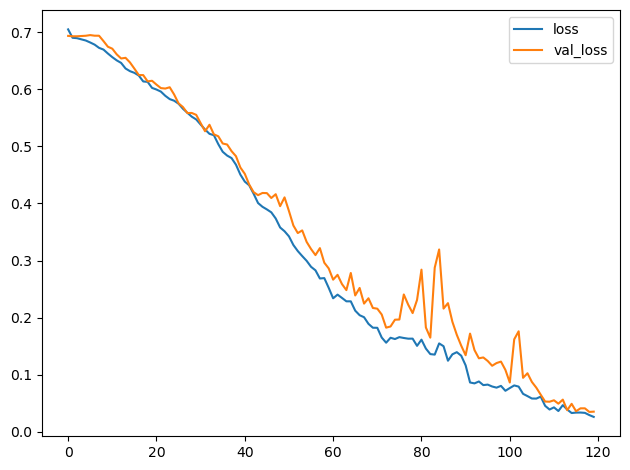

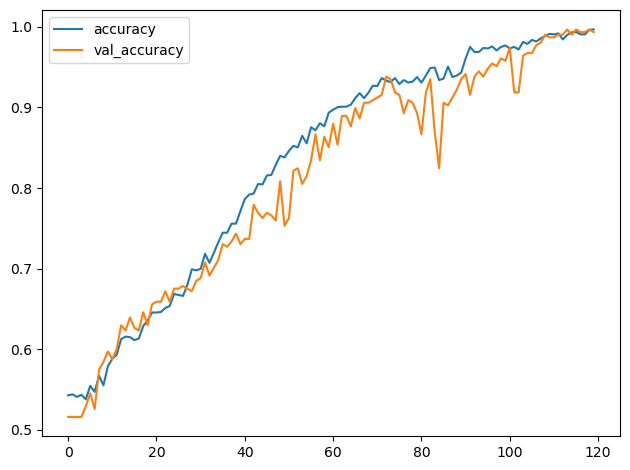

In [12]:
import pandas as pd
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot();

In [13]:
ds_test_ = image_dataset_from_directory(
    '/kaggle/input/stft-sz12/STFT_SZ/test',
    labels='inferred',
    label_mode='binary',
    image_size=[227,227],
    interpolation='nearest',
    batch_size=64,
    shuffle=False,
)
ds_test = (
    ds_valid_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

Found 308 files belonging to 2 classes.


In [14]:
D=r"/kaggle/input/stft-sz12/STFT_SZ/test"
C=['Norm_STFT_Spectrogram','SZ-STFT_Spectrogram']

In [15]:
import cv2


In [16]:
IMG_SIZE=227
data=[]
for c in C:
    f=os.path.join(D,c)
    label=C.index(c)
    for img in os.listdir(f):
        img_path=os.path.join(f,img)
        img_arr=cv2.imread(img_path)
        img_arr=cv2.resize(img_arr,(IMG_SIZE,IMG_SIZE))
        data.append([img_arr,label])

X=[]
y=[]
for features,labels in data:
    X.append(features)
    y.append(labels)
X=np.array(X)
y=np.array(y)
X=X/255
X.shape

(308, 227, 227, 3)

In [17]:
k=model.predict(ds_valid)
yp=[np.argmax(e)for e in k]
print(yp)

5/5 [==============================] - 0s 27ms/step
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [18]:
from sklearn.metrics import confusion_matrix, classification_report
report = classification_report(y, yp)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       149
           1       0.99      1.00      0.99       159

    accuracy                           0.99       308
   macro avg       0.99      0.99      0.99       308
weighted avg       0.99      0.99      0.99       308



Text(9.444444444444452, 0.5, 'Truth')

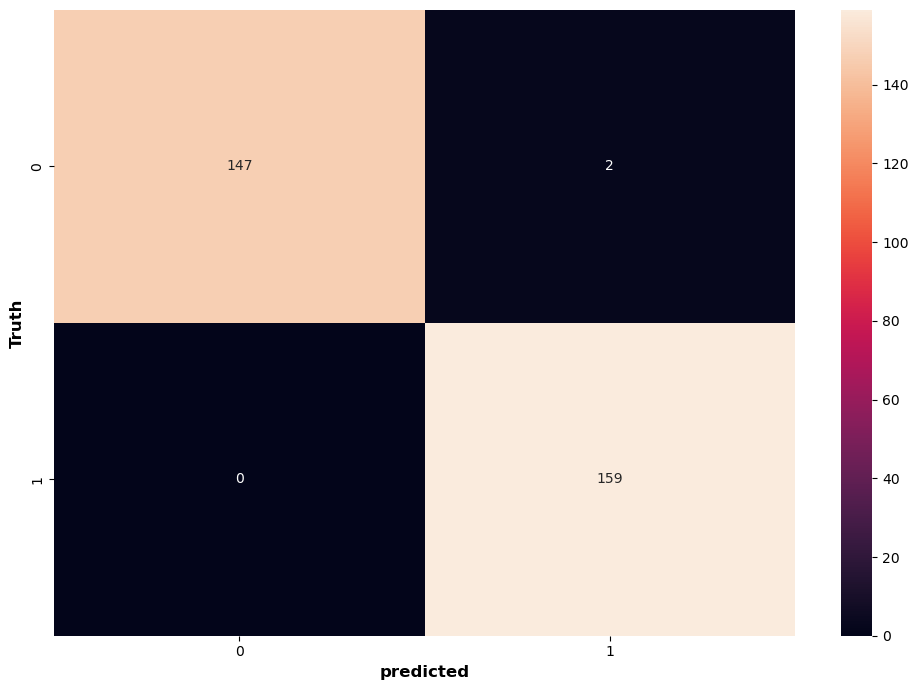

In [19]:
import tensorflow
cm=tensorflow.math.confusion_matrix(labels=y,predictions=yp)
cm
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True,fmt='d')
plt.xlabel('predicted')
plt.ylabel('Truth')

In [20]:
(125+136)/308

0.8474025974025974